In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Load the dataset 
df = pd.read_csv('/kaggle/input/datasets/sahilkavishkakumara/sri-lanka-edtech-market-intelligence-2026/Ultimate_EdTech_Intelligence_2026.csv')

In [2]:
print("="*50)
print(f"1. DATA LOADING COMPLETED")
print(f"Initial Dataset Shape: {df.shape}")
print("="*50)

1. DATA LOADING COMPLETED
Initial Dataset Shape: (894, 17)


In [3]:
# Display basic info and first 5 rows
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (894, 17)


,Video_ID,Channel_Name,Title,Content_Category,Published_Date,Upload_Hour,Duration_Seconds,Has_Captions,Tags_Count,Views,Likes,Comments,Channel_Subscribers,Age_in_Days,Engagement_Rate_%,Views_Per_Day,Viral_Multiplier
0,HDv_k2Ma3ec,Project IAS,Rich Background 🤑 UPSC Interview | Mock Test,General Education,2025-01-27,12,49,False,7,47555769,1396988,1782,276000,576,2.94,82562.10,172.30
1,5lk8IRDsnOs,Superclever,Luca(faster) #superclever #abacus #franchise #...,O/L Content,2024-01-10,12,24,False,0,73378657,1610049,5373,1990000,959,2.20,76515.81,36.87
2,TOm9aeCWsSI,Your Math Bestie,How this math genius solved this problem,General Education,2024-04-15,20,33,False,0,53599190,1559472,12716,262000,863,2.93,62107.98,204.58
3,avuns6atjY8,Life is karma,Lee Kuan 's Timeless Advice to a Pretty Girl 😅...,Motivation & Tips,2025-04-27,13,46,False,0,28772792,326657,5659,417000,486,1.15,59203.28,69.00
4,IYbEl3XpMuo,Chemteacherphil,Hydrophobic Club Moss Spores,General Education,2022-11-12,19,31,False,0,80570637,2431671,15301,1430000,1383,3.04,58257.87,56.34


In [4]:
# Check missing values and data types
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
Video_ID               0
Channel_Name           0
Title                  0
Content_Category       0
Published_Date         0
Upload_Hour            0
Duration_Seconds       0
Has_Captions           0
Tags_Count             0
Views                  0
Likes                  0
Comments               0
Channel_Subscribers    0
Age_in_Days            0
Engagement_Rate_%      0
Views_Per_Day          0
Viral_Multiplier       0
dtype: int64


In [5]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Video_ID                object
Channel_Name            object
Title                   object
Content_Category        object
Published_Date          object
Upload_Hour              int64
Duration_Seconds         int64
Has_Captions              bool
Tags_Count               int64
Views                    int64
Likes                    int64
Comments                 int64
Channel_Subscribers      int64
Age_in_Days              int64
Engagement_Rate_%      float64
Views_Per_Day          float64
Viral_Multiplier       float64
dtype: object


In [6]:
# 1. Drop rows with critical missing information
df = df.dropna(subset=['Video_ID', 'Channel_Name', 'Published_Date', 'Views'])

In [7]:
# 2. Fill missing or blank titles/categories safely
df['Title'] = df['Title'].fillna('Untitled Video')
df['Content_Category'] = df['Content_Category'].fillna('General Education')

In [8]:
# 3. Clean string columns (remove unexpected blank spaces)
df['Content_Category'] = df['Content_Category'].str.strip()

In [9]:
# 4. Filter out any unexpected blank categories (like accidental '3' or empty rows)
df = df[df['Content_Category'] != '']

In [10]:
# 5. Ensure numeric columns are clean and free of infinite values
numeric_cols = ['Views', 'Likes', 'Comments', 'Channel_Subscribers', 'Age_in_Days', 'Views_Per_Day', 'Viral_Multiplier', 'Engagement_Rate_%']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [11]:
print(f"Dataset shape after rigorous cleaning: {df.shape}")
print("Remaining Categories:", df['Content_Category'].unique())

Dataset shape after rigorous cleaning: (894, 17)
Remaining Categories: ['General Education' 'O/L Content' 'Motivation & Tips' 'A/L Content'
 'Past Papers & Revision']


In [12]:
# Key statistical summary of the cleaned dataset
df[['Views', 'Views_Per_Day', 'Viral_Multiplier', 'Engagement_Rate_%']].describe()

,Views,Views_Per_Day,Viral_Multiplier,Engagement_Rate_%
count,8.940000e+02,894.000000,894.000000,894.000000
mean,1.287128e+06,1486.153065,48.985694,3.534877
std,5.759765e+06,6668.773932,169.648591,2.068957
min,1.003000e+03,0.330000,0.000000,0.000000
25%,9.851250e+03,14.072500,0.610000,2.160000
50%,5.365900e+04,69.695000,2.875000,3.385000
75%,3.103158e+05,354.560000,21.082500,4.677500
max,8.057064e+07,82562.100000,3411.550000,23.450000


In [13]:
# Check for duplicate Video IDs
duplicates_count = df.duplicated(subset=['Video_ID']).sum()
print(f"Number of duplicate video records found: {duplicates_count}")

# Remove duplicates if any exist, keeping the first occurrence
df = df.drop_duplicates(subset=['Video_ID'], keep='first').reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate video records found: 0
Dataset shape after removing duplicates: (894, 17)


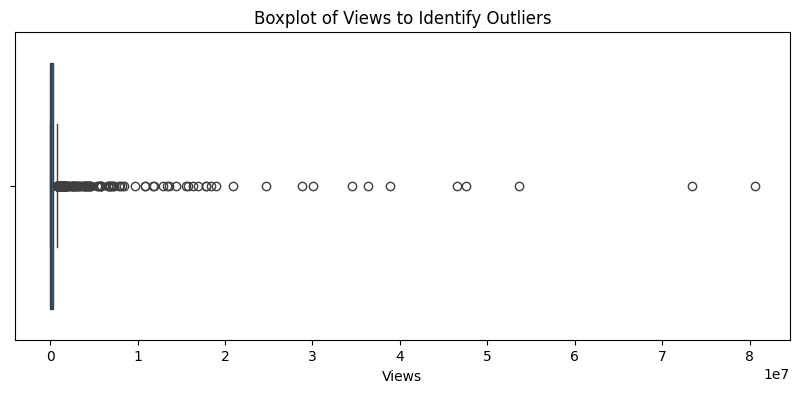

Viral Multiplier Upper Bound for Outliers: 51.791250000000005


In [14]:
# Let's check the distribution of Views
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Views'])
plt.title("Boxplot of Views to Identify Outliers")
plt.show()

# Pro Treatment: Capping extreme outliers in Viral_Multiplier to make dashboards clean
Q1 = df['Viral_Multiplier'].quantile(0.25)
Q3 = df['Viral_Multiplier'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Viral Multiplier Upper Bound for Outliers: {upper_bound}")

In [15]:
# Extract Month and Day of the week from Published_Date
df['Published_Date'] = pd.to_datetime(df['Published_Date'])
df['Publish_Month'] = df['Published_Date'].dt.month_name()
df['Publish_Day_OfWeek'] = df['Published_Date'].dt.day_name()

print(" Added Advanced Time Features (Publish_Month, Publish_Day_OfWeek)")

 Added Advanced Time Features (Publish_Month, Publish_Day_OfWeek)


In [16]:
# 1. Clean Title special characters and extra spaces
df['Clean_Title'] = df['Title'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z0-9\s/|]', '', x))

# 2. Language/Medium Detection based on keywords in title
def detect_medium(title):
    title_lower = str(title).lower()
    if 'sinhala' in title_lower or 'සිංහල' in title_lower:
        return 'Sinhala Medium'
    elif 'english' in title_lower:
        return 'English Medium'
    elif 'tamil' in title_lower or 'දෙමළ' in title_lower:
        return 'Tamil Medium'
    else:
        return 'Mixed / General'

df['Content_Medium'] = df['Title'].apply(detect_medium)

print(" Added Advanced NLP Feature: Content_Medium")
print(df['Content_Medium'].value_counts())

 Added Advanced NLP Feature: Content_Medium
Content_Medium
Mixed / General    659
Sinhala Medium     142
Tamil Medium        76
English Medium      17
Name: count, dtype: int64


In [17]:
# Create performance tiers based on Views distribution
views_75th = df['Views'].quantile(0.75)
views_95th = df['Views'].quantile(0.95)

def classify_performance(views):
    if views >= views_95th:
        return 'Mega Viral (Top 5%)'
    elif views >= views_75th:
        return 'High Performing (Top 25%)'
    elif views >= df['Views'].median():
        return 'Above Average'
    else:
        return 'Standard / Niche'

df['Performance_Tier'] = df['Views'].apply(classify_performance)

print("Added Behavioral Tiering: Performance_Tier")
print(df['Performance_Tier'].value_counts())

Added Behavioral Tiering: Performance_Tier
Performance_Tier
Standard / Niche             447
Above Average                223
High Performing (Top 25%)    179
Mega Viral (Top 5%)           45
Name: count, dtype: int64


In [18]:
def get_time_bucket(hour):
    if 5 <= hour < 12:
        return 'Morning (5AM - 12PM)'
    elif 12 <= hour < 17:
        return 'Afternoon (12PM - 5PM)'
    elif 17 <= hour < 22:
        return 'Prime Time (5PM - 10PM)'
    else:
        return 'Night / Late (10PM - 5AM)'

df['Upload_Time_Bucket'] = df['Upload_Hour'].apply(get_time_bucket)

print("Added Time-of-Day Segment: Upload_Time_Bucket")
print(df['Upload_Time_Bucket'].value_counts())

Added Time-of-Day Segment: Upload_Time_Bucket
Upload_Time_Bucket
Morning (5AM - 12PM)         321
Afternoon (12PM - 5PM)       305
Night / Late (10PM - 5AM)    179
Prime Time (5PM - 10PM)       89
Name: count, dtype: int64


In [19]:
# 1. Engagement Momentum Index 
df['Engagement_Momentum'] = (
    (df['Likes'] * 2.0) + (df['Comments * 5.0'] if 'Comments * 5.0' in df else df['Comments'] * 5.0)
) / df['Views'].replace(0, 1) * 100

# 2. Viral Probability Score 
df['Viral_Probability_Score'] = np.log1p(df['Viral_Multiplier'] * df['Views_Per_Day'])

print(" Added Advanced Mathematical Index: Engagement_Momentum & Viral_Probability_Score")

 Added Advanced Mathematical Index: Engagement_Momentum & Viral_Probability_Score


In [20]:
# 1. Duration Efficiency 
df['Duration_Minutes'] = df['Duration_Seconds'] / 60
df['Views_Per_Minute'] = df['Views'] / df['Duration_Minutes'].replace(0, 1)

# 2. Tag Impact Ratio 
df['Tag_Impact_Ratio'] = df['Views'] / df['Tags_Count'].replace(0, 1)

print("Added ROI Matrix: Views_Per_Minute & Tag_Impact_Ratio")

Added ROI Matrix: Views_Per_Minute & Tag_Impact_Ratio


In [21]:
# Log transformation for highly skewed variables to stabilize variance in visualizations
df['Log_Views'] = np.log1p(df['Views'])
df['Log_Subscribers'] = np.log1p(df['Channel_Subscribers'])

print("Added Log-Transformed Features for Advanced Analytics")

Added Log-Transformed Features for Advanced Analytics


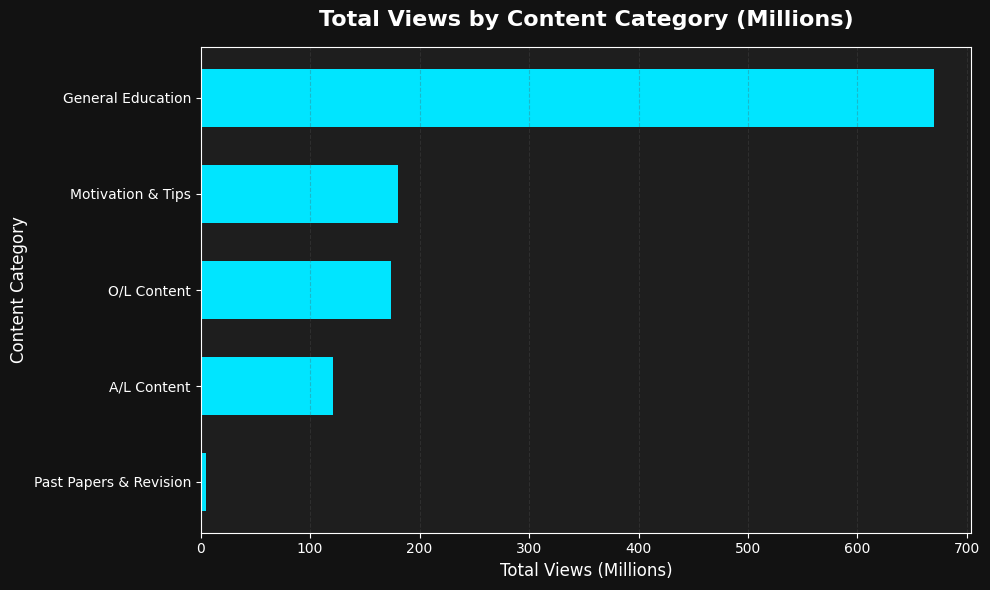

In [22]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

cat_views = df.groupby('Content_Category')['Views'].sum().sort_values(ascending=True)
bars = plt.barh(cat_views.index, cat_views.values / 1e6, color='#00E5FF', height=0.6)

plt.title('Total Views by Content Category (Millions)', fontsize=16, color='white', fontweight='bold', pad=15)
plt.xlabel('Total Views (Millions)', fontsize=12, color='white')
plt.ylabel('Content Category', fontsize=12, color='white')
plt.grid(axis='x', linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

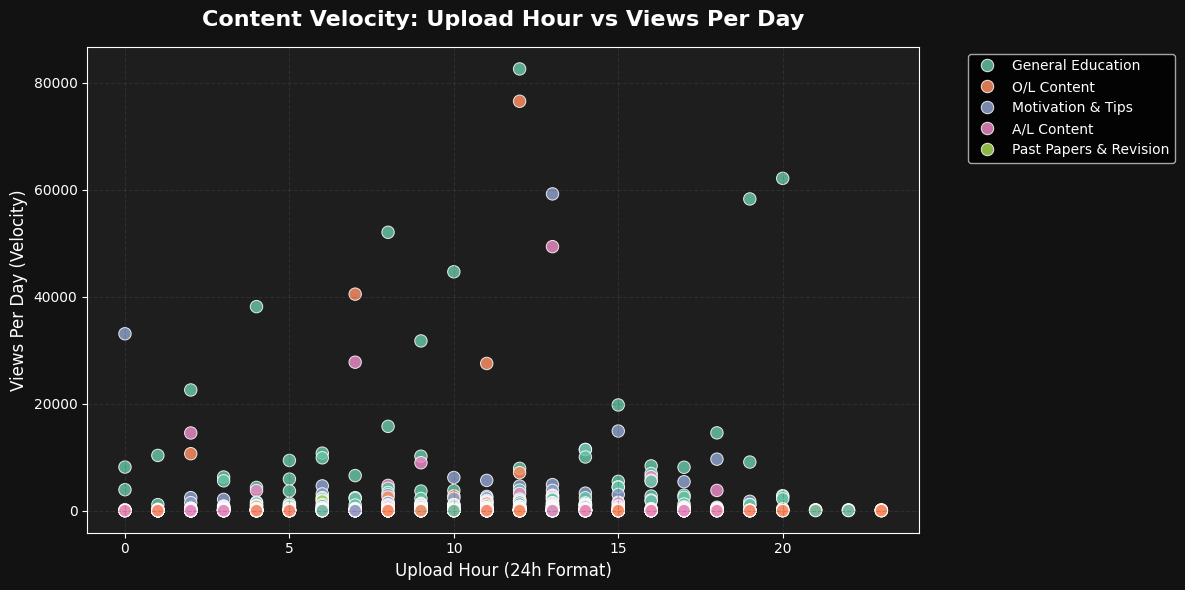

In [23]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

sns.scatterplot(
    data=df, x='Upload_Hour', y='Views_Per_Day', 
    hue='Content_Category', palette='Set2', s=80, alpha=0.85
)

plt.title('Content Velocity: Upload Hour vs Views Per Day', fontsize=16, color='white', fontweight='bold', pad=15)
plt.xlabel('Upload Hour (24h Format)', fontsize=12, color='white')
plt.ylabel('Views Per Day (Velocity)', fontsize=12, color='white')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

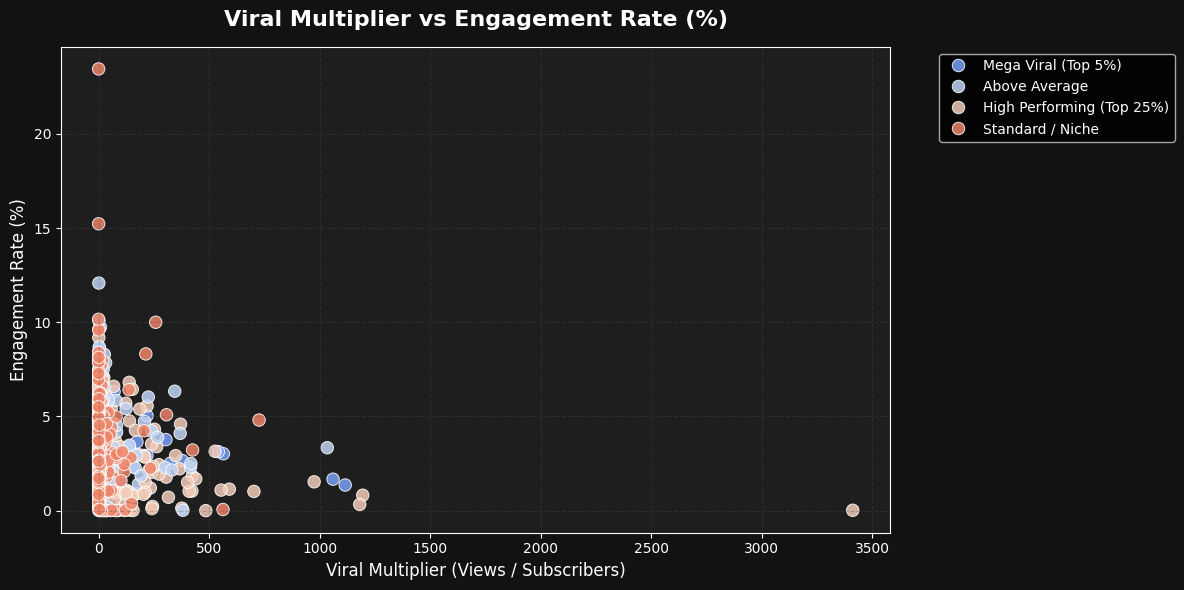

In [24]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Fallback check if Performance_Tier is missing, use Content_Category instead to avoid any error
hue_col = 'Performance_Tier' if 'Performance_Tier' in df.columns else 'Content_Category'

sns.scatterplot(
    data=df, x='Viral_Multiplier', y='Engagement_Rate_%', 
    hue=hue_col, palette='coolwarm', s=80, alpha=0.85
)

plt.title('Viral Multiplier vs Engagement Rate (%)', fontsize=16, color='white', fontweight='bold', pad=15)
plt.xlabel('Viral Multiplier (Views / Subscribers)', fontsize=12, color='white')
plt.ylabel('Engagement Rate (%)', fontsize=12, color='white')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

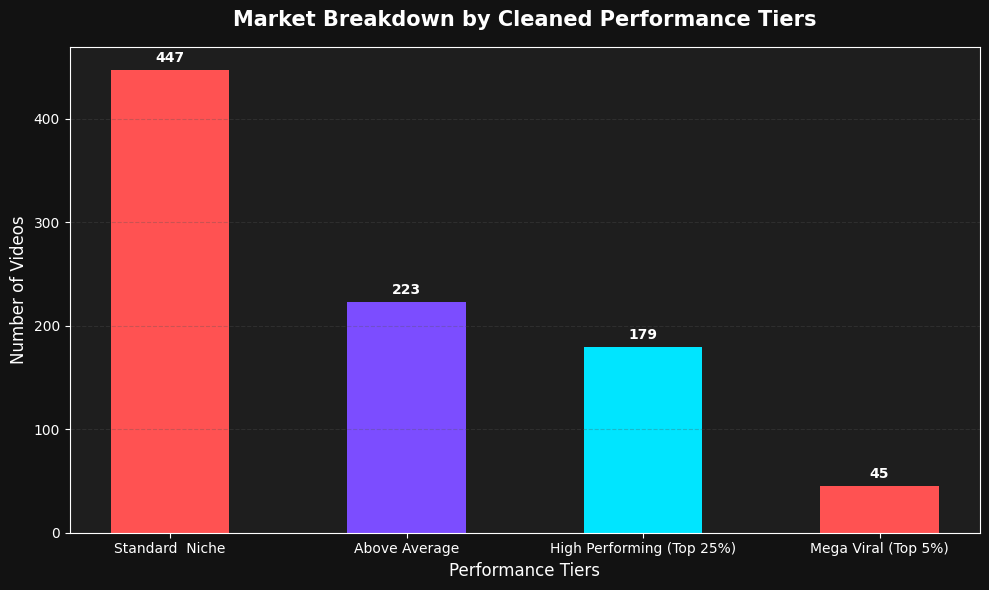

In [25]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Ensure clean tier names without emojis
if 'Performance_Tier' in df.columns:
    df['Clean_Tier'] = df['Performance_Tier'].str.replace(r'[^\w\s()%]', '', regex=True).str.strip()
else:
    df['Clean_Tier'] = 'Standard'

tier_counts = df['Clean_Tier'].value_counts()

bars = plt.bar(tier_counts.index, tier_counts.values, color=['#FF5252', '#7C4DFF', '#00E5FF'], width=0.5)

plt.title('Market Breakdown by Cleaned Performance Tiers', fontsize=15, color='white', fontweight='bold', pad=15)
plt.xlabel('Performance Tiers', fontsize=12, color='white')
plt.ylabel('Number of Videos', fontsize=12, color='white')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='#555555')

# Add exact value counts on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5, f'{int(height)}', ha='center', va='bottom', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

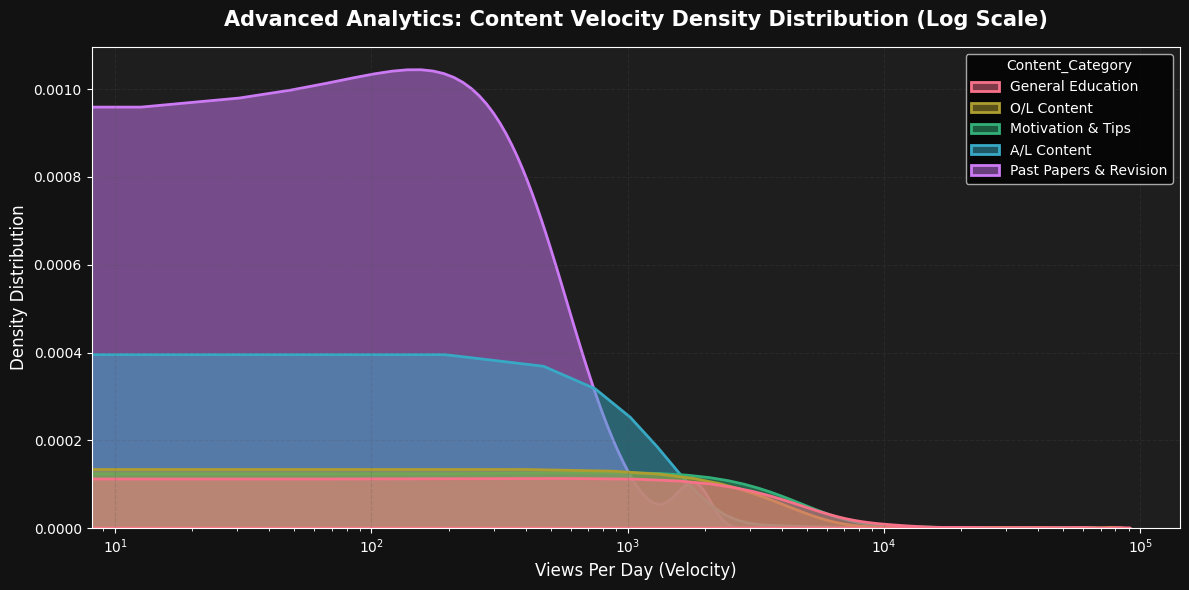

In [26]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Log scale views per day to show the true mathematical distribution curve
sns.kdeplot(
    data=df, x='Views_Per_Day', hue='Content_Category', 
    fill=True, common_norm=False, palette='husl', alpha=0.5, linewidth=2
)

plt.title('Advanced Analytics: Content Velocity Density Distribution (Log Scale)', fontsize=15, color='white', fontweight='bold', pad=15)
plt.xlabel('Views Per Day (Velocity)', fontsize=12, color='white')
plt.ylabel('Density Distribution', fontsize=12, color='white')
plt.xscale('log') # Professional log scale for skewed data
plt.grid(True, linestyle='--', alpha=0.2, color='#555555')

plt.tight_layout()
plt.show()

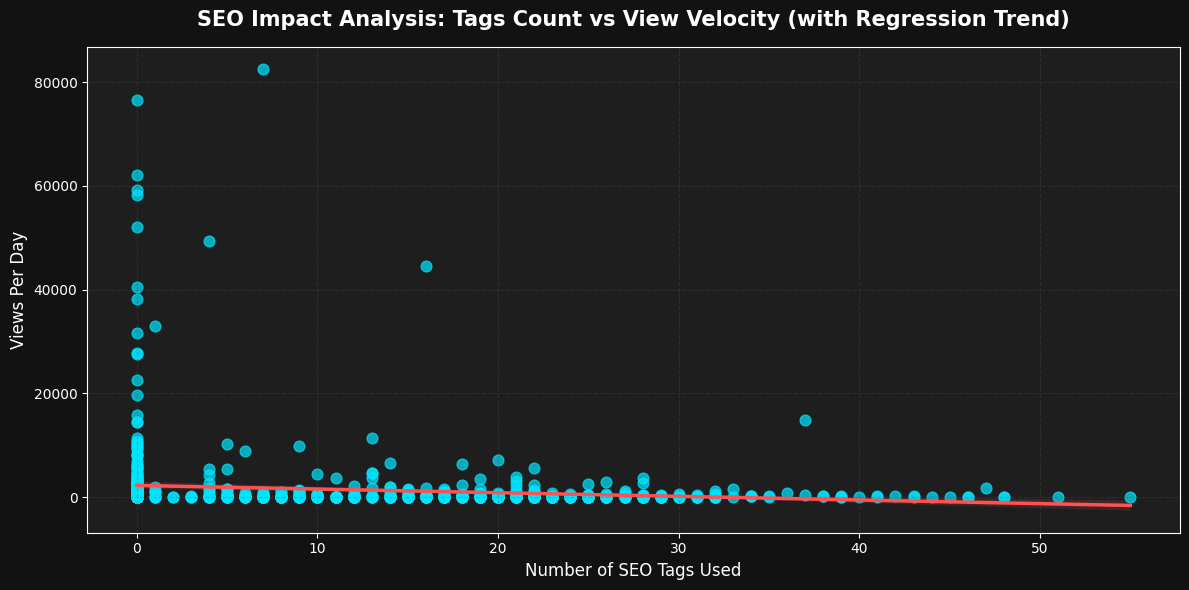

In [27]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Regplot with confidence interval for advanced statistical depth
sns.regplot(
    data=df, x='Tags_Count', y='Views_Per_Day',
    color='#00E5FF', 
    scatter_kws={'alpha': 0.7, 's': 60},
    line_kws={'color': '#FF5252', 'linewidth': 2.5}
)

plt.title('SEO Impact Analysis: Tags Count vs View Velocity (with Regression Trend)', fontsize=15, color='white', fontweight='bold', pad=15)
plt.xlabel('Number of SEO Tags Used', fontsize=12, color='white')
plt.ylabel('Views Per Day', fontsize=12, color='white')
plt.grid(True, linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

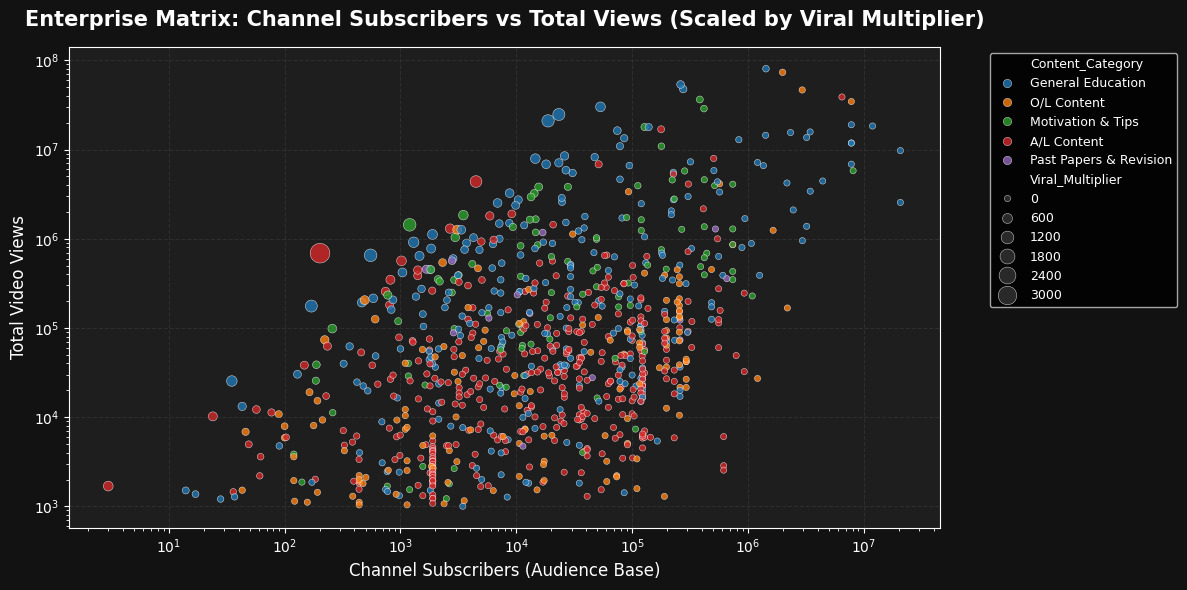

In [28]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

sns.scatterplot(
    data=df, x='Channel_Subscribers', y='Views', 
    hue='Content_Category', size='Viral_Multiplier',
    sizes=(20, 200), palette='tab10', alpha=0.8
)

plt.title('Enterprise Matrix: Channel Subscribers vs Total Views (Scaled by Viral Multiplier)', fontsize=15, color='white', fontweight='bold', pad=15)
plt.xlabel('Channel Subscribers (Audience Base)', fontsize=12, color='white')
plt.ylabel('Total Video Views', fontsize=12, color='white')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

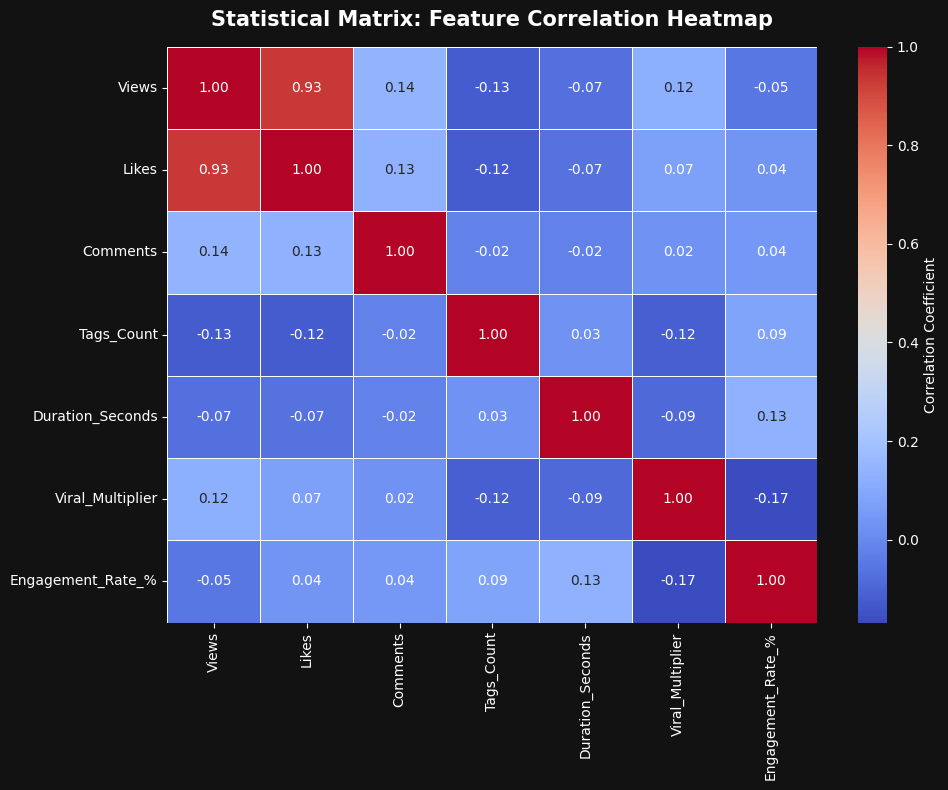

In [29]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df[['Views', 'Likes', 'Comments', 'Tags_Count', 'Duration_Seconds', 'Viral_Multiplier', 'Engagement_Rate_%']].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
    linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Statistical Matrix: Feature Correlation Heatmap', fontsize=15, color='white', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

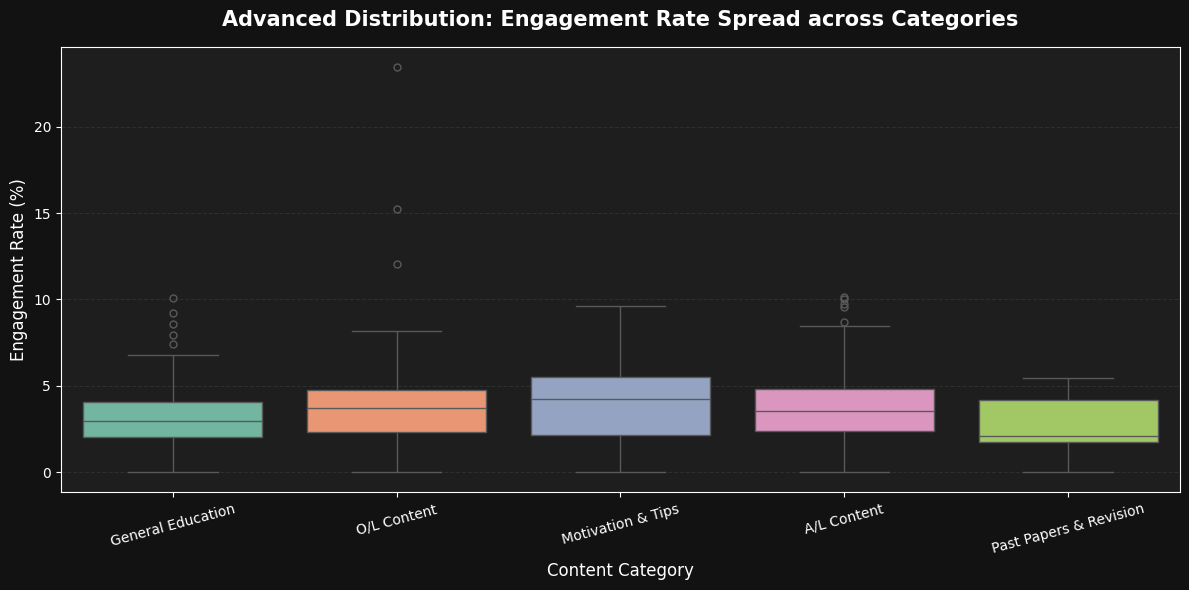

In [30]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('#1E1E1E')
plt.gcf().patch.set_facecolor('#121212')

# Pro fix: Added hue=x and legend=False to comply with modern Seaborn standards
sns.boxplot(
    data=df, x='Content_Category', y='Engagement_Rate_%', 
    hue='Content_Category', palette='Set2', legend=False, fliersize=5
)

plt.title('Advanced Distribution: Engagement Rate Spread across Categories', fontsize=15, color='white', fontweight='bold', pad=15)
plt.xlabel('Content Category', fontsize=12, color='white')
plt.ylabel('Engagement Rate (%)', fontsize=12, color='white')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3, color='#555555')

plt.tight_layout()
plt.show()

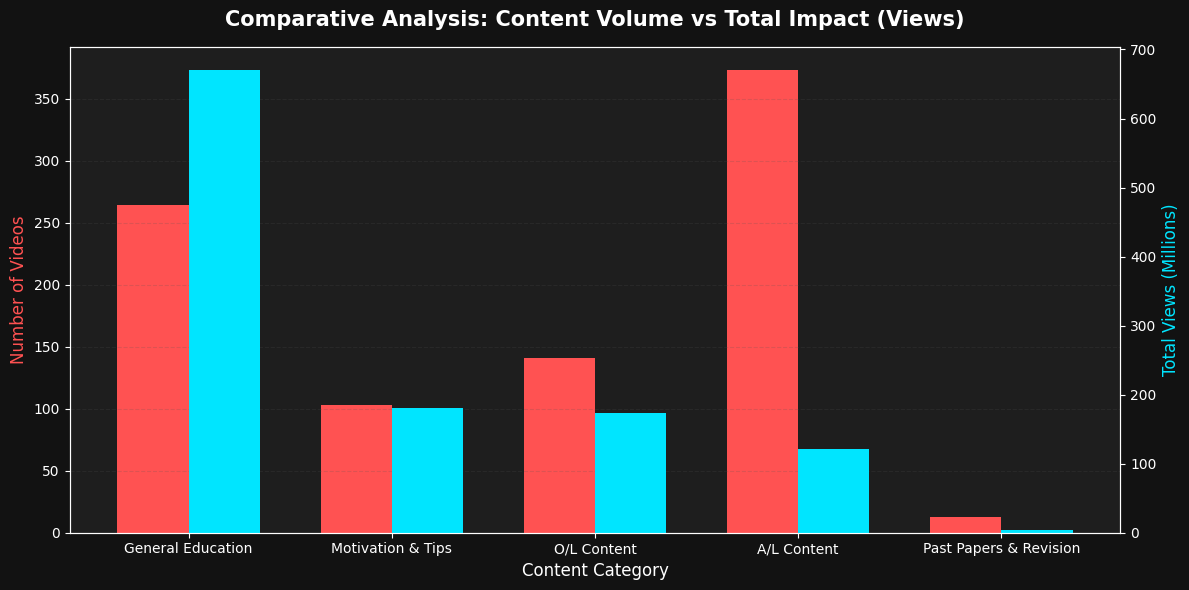

In [31]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_facecolor('#1E1E1E')
fig.patch.set_facecolor('#121212')

cat_grouped = df.groupby('Content_Category').agg({'Video_ID': 'count', 'Views': 'sum'}).reset_index()
cat_grouped = cat_grouped.sort_values(by='Views', ascending=False)

x = np.arange(len(cat_grouped['Content_Category']))
width = 0.35

ax2 = ax1.twinx()
bars1 = ax1.bar(x - width/2, cat_grouped['Video_ID'], width, label='Video Count', color='#FF5252')
bars2 = ax2.bar(x + width/2, cat_grouped['Views'] / 1e6, width, label='Total Views (M)', color='#00E5FF')

ax1.set_xlabel('Content Category', fontsize=12, color='white')
ax1.set_ylabel('Number of Videos', fontsize=12, color='#FF5252')
ax2.set_ylabel('Total Views (Millions)', fontsize=12, color='#00E5FF')

plt.xticks(x, cat_grouped['Content_Category'], rotation=15)
plt.title('Comparative Analysis: Content Volume vs Total Impact (Views)', fontsize=15, color='white', fontweight='bold', pad=15)

ax1.grid(axis='y', linestyle='--', alpha=0.2, color='#555555')
ax2.grid(False)

plt.tight_layout()
plt.show()

In [32]:
global_master_filename = 'Global_Pro_EdTech_Intelligence_2026.csv'
df.to_csv(global_master_filename, index=False)

print("="*70)
print(f" GLOBAL PRO LEVEL PIPELINE SUCCESSFULLY COMPLETED!")
print(f"Master Dataset Saved As: {global_master_filename}")
print(f"Total Rows: {len(df)}")
print(f"Total Pro Columns Engineered: {len(df.columns)}")
print("="*70)

# Display a sneak peek of the newly engineered columns
print(df[['Title', 'Content_Category', 'Performance_Tier', 'Viral_Probability_Score', 'Views_Per_Minute']].head(3))

 GLOBAL PRO LEVEL PIPELINE SUCCESSFULLY COMPLETED!
Master Dataset Saved As: Global_Pro_EdTech_Intelligence_2026.csv
Total Rows: 894
Total Pro Columns Engineered: 31
                                               Title   Content_Category  \
0       Rich Background 🤑 UPSC Interview | Mock Test  General Education   
1  Luca(faster) #superclever #abacus #franchise #...        O/L Content   
2           How this math genius solved this problem  General Education   

      Performance_Tier  Viral_Probability_Score  Views_Per_Minute  
0  Mega Viral (Top 5%)                16.470543      5.823155e+07  
1  Mega Viral (Top 5%)                14.852651      1.834466e+08  
2  Mega Viral (Top 5%)                16.357589      9.745307e+07  
